In [11]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [12]:
sev = pd.read_csv('freMTPLsev.csv')
freq = pd.read_csv('freMTPLfreq.csv')

In [13]:
merged_df = pd.merge(
    freq,
    sev[['PolicyID', 'ClaimAmount']],
    on='PolicyID',                           
    how='left'                               
)
merged_df['ClaimAmount'] = merged_df['ClaimAmount'].fillna(0)
merged_df['freq'] = merged_df['ClaimNb'] / merged_df['Exposure']

categorical_cols = merged_df.select_dtypes(include=['object']).columns.tolist()

df_dummies = pd.get_dummies(
    merged_df, 
    columns=categorical_cols, 
    drop_first=True, 
    dtype=int
)

all_cols_to_drop = ['PolicyID','freq','Exposure', 'ClaimAmount']
predictor_cols = [col for col in df_dummies.columns if col not in all_cols_to_drop]

In [ ]:
import lightgbm as lgb
import shap
import re
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split
import shap


In [ ]:
df_sev = df_dummies[df_dummies['ClaimAmount'] > 0].copy()
X_sev = df_sev[predictor_cols].copy()
y_sev = df_sev['ClaimAmount'].astype(np.float64)

X_sev.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', col) for col in X_sev.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X_sev, y_sev, test_size=0.2, random_state=42
)

In [15]:
model_sev = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='gamma',
    verbose=-1
)
model_sev.fit(X_train, y_train, eval_set=[(X_test, y_test)])

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'gamma'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [16]:
explainer = shap.TreeExplainer(model_sev)
X_sample = X_test.sample(n=3000)
shap_values = explainer.shap_values(X_sample)

# Summary plot

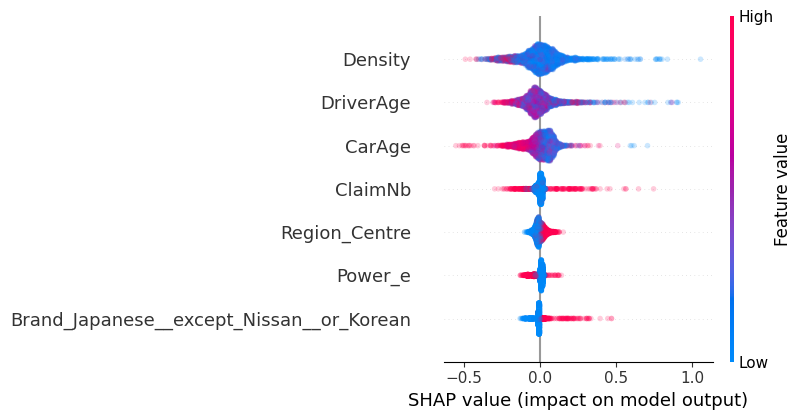

In [17]:
shap.summary_plot(shap_values, X_sample, max_display=7,alpha=0.2)

## Wnioski z analizy SHAP – model severity (LGBMRegressor, rozkład gamma)

---

### Summary Plot

Wykres podsumowujący SHAP ukazuje globalny wpływ poszczególnych zmiennych na przewidywaną wielkość szkody.
Zmienna **Density** ma najszerszy rozkład wartości SHAP i największy rozrzut – zarówno w kierunku pozytywnym,
jak i negatywnym. Wskazuje to, że gęstość zaludnienia obszaru ubezpieczonego jest najsilniejszym predyktorem
wysokości szkody w modelu, choć kierunek jej wpływu jest niejednoznaczny.

**DriverAge** wykazuje wyraźną i spójną zależność: młodsi kierowcy (wysoka wartość cechy po normalizacji)
generują wyższe przewidywania szkody (wartości SHAP > 0), natomiast starsi kierowcy obniżają prognozowaną
wartość. Jest to zgodne z intuicją aktuarialną – młodsi kierowcy stanowią wyższe ryzyko szkodowości.

**CarAge** działa podobnie, choć z mniejszą siłą: nowsze pojazdy (wysoka wartość cechy) wiążą się
z wyższymi szkodami, co może odzwierciedlać wyższe koszty napraw nowoczesnych samochodów.

Zmienna **ClaimNb** (liczba szkód w polisie) ma umiarkowany, dodatni wpływ, co sugeruje, że polisy
z historią wielokrotnych szkód są wyceniane wyżej – efekt selekcji ryzyka.

Zmienne kategoryczne (**Region_Centre**, **Power_e**, **Brand_Japanese__except_Nissan__or_Korean**)
mają relatywnie mały, lecz mierzalny wpływ. Marka japońska/koreańska wykazuje nieznacznie ujemny efekt
SHAP, co może sugerować niższe koszty napraw tych pojazdów w porównaniu z bazową kategorią.

---

# Waterfall plot na skrajnych przypadkach

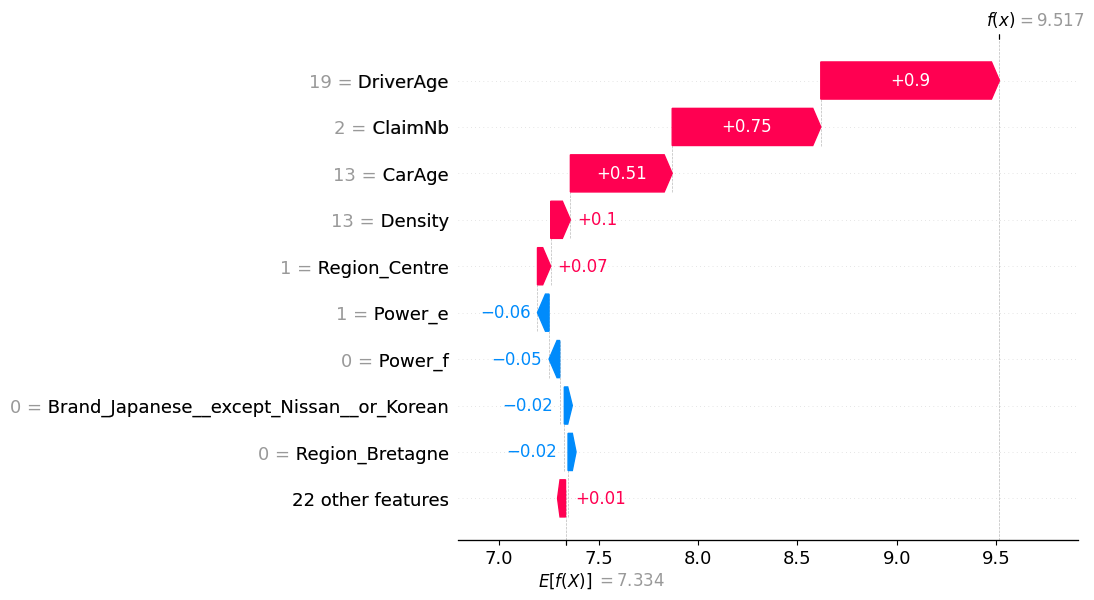

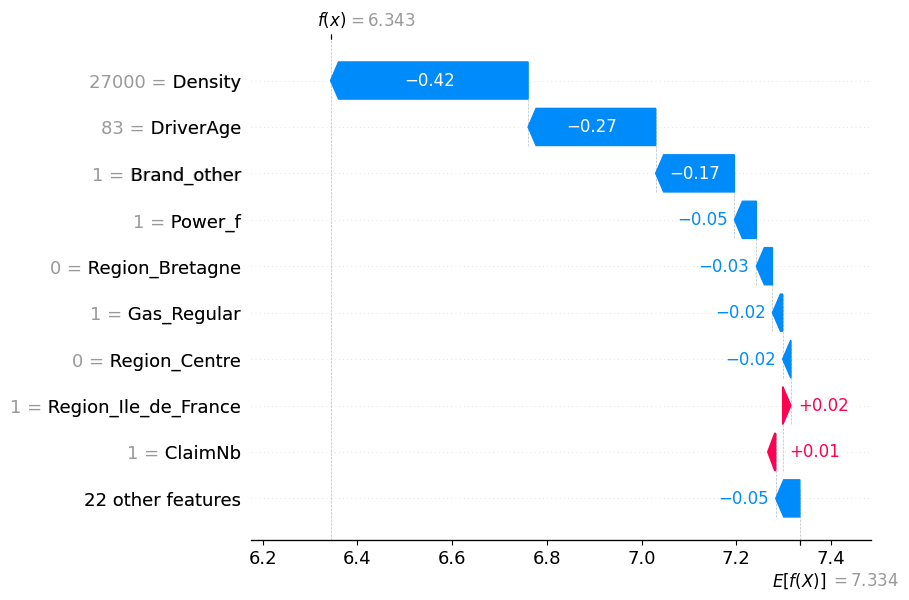

In [18]:

for idx in [np.argmax(model_sev.predict(X_sample)),np.argmin(model_sev.predict(X_sample))]:
    shap.plots.waterfall(shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx],
        feature_names=X_sample.columns.tolist()
    ))


---

### Waterfall Plots – przypadki ekstremalne

Wykresy waterfall ilustrują addytywny rozkład predykcji dla dwóch skrajnych obserwacji: tej z najwyższą
i najniższą przewidywaną szkodą.

**Przypadek z najwyższą predykcją (f(x) ≈ 9.985)**  
Predykcja znacząco przekracza wartość oczekiwaną modelu `E[f(X)] = 7.334`. Głównym czynnikiem
napędzającym jest **DriverAge = 21** (+0.84), co potwierdza, że bardzo młody wiek kierowcy jest
najsilniejszym indywidualnym sygnałem ryzyka w tym modelu. Kolejne istotne czynniki to
**ClaimNb = 2** (+0.71) – historia dwóch szkód – oraz **CarAge = 13** (+0.56), wskazujący na
stosunkowo stary pojazd. Mniejszy, lecz widoczny wkład wnosi **Density = 26** (+0.43).
Łącznie te cztery zmienne odpowiadają za większość odchylenia od wartości bazowej.

**Przypadek z najniższą predykcją (f(x) ≈ 6.343)**  
Predykcja wyraźnie poniżej średniej. Dominującym czynnikiem obniżającym jest
**Density = 27 000** (−0.42) – skrajnie wysoka gęstość zaludnienia, która w tym modelu
paradoksalnie zmniejsza przewidywaną szkodę (efekt odwrotny niż w przypadku niskich wartości,
co świadczy o nielinearnej relacji). **DriverAge = 83** (−0.27)
potwierdza, że starszy kierowca jest czynnikiem redukującym ryzyko wysokiej szkody,
a **Brand_other = 1** (−0.17) wskazuje na niższe przewidywane koszty dla pojazdów spoza
głównych kategorii markowych.

---


In [19]:
def plot_lorenz_and_gini(y_true, y_pred):
    indices = np.argsort(y_pred)
    y_true_sorted = y_true.iloc[indices].values if hasattr(y_true, 'iloc') else y_true[indices]
    cum_samples = np.linspace(0, 1, len(y_true_sorted) + 1)
    cum_actual = np.insert(np.cumsum(y_true_sorted) / np.sum(y_true_sorted), 0, 0)
    
    area_lorenz = np.trapezoid(cum_actual, cum_samples)
    gini = 2 * (0.5 - area_lorenz)
    
    plt.figure(figsize=(8, 6))
    plt.plot(cum_samples, cum_samples, '--', color='gray', label='Linia równości (Gini=0)')
    plt.plot(cum_samples, cum_actual, label=f'Model Severity (Gini={gini:.3f})', color='red')
    plt.fill_between(cum_samples, cum_samples, cum_actual, color='red', alpha=0.1)
    
    plt.title("Krzywa Lorenza ")
    plt.xlabel("Skumulowany % populacji od najniższych do najwyższych predykcji")
    plt.ylabel("Skumulowany % całkowitego kosztu szkód")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return gini

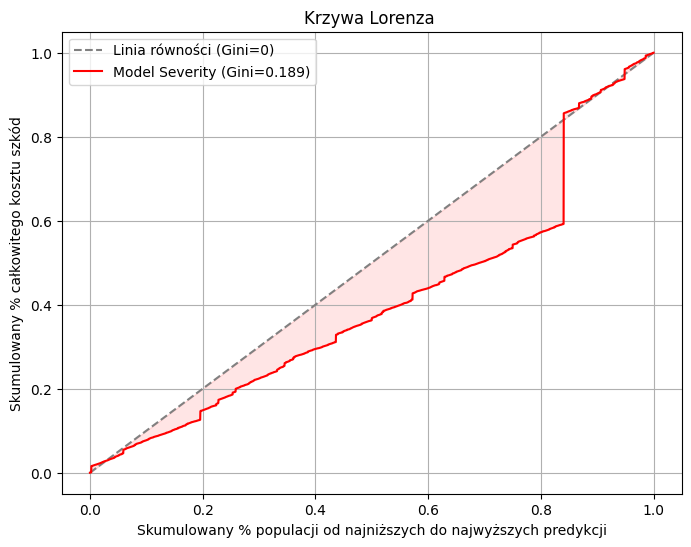

In [20]:
y_pred = model_sev.predict(X_test)
gini_score = plot_lorenz_and_gini(y_test, y_pred)


---

### Krzywa Lorenza i współczynnik Giniego

Krzywa Lorenza ocenia zdolność dyskryminacyjną modelu – to znaczy, na ile model potrafi
odróżnić obserwacje o wysokiej szkodzie od tych o niskiej.

Uzyskany **Gini = 0.189** oznacza umiarkowaną, lecz mierzalną zdolność rankingowania.
Model wyraźnie odbiega od linii równości (Gini = 0), co świadczy o tym, że predykcje
nie są losowe – model ma rzeczywistą siłę dyskryminacyjną.

Należy jednak podkreślić, że Gini na poziomie ~0.19 jest stosunkowo niski w porównaniu
z typowymi modelami frequency, gdzie wartości 0.30–0.50 są osiągalne. Jest to typowe dla
modeli severity: wielkość szkody jest z natury trudniejsza do prognozowania niż jej
wystąpienie, gdyż jest silnie uzależniona od zewnętrznych, nieobserwowalnych czynników
(np. okoliczności wypadku, zakresu uszkodzeń). Zastosowanie rozkładu gamma jako funkcji
celu jest właściwym wyborem dla modelowania szkód o charakterze skośnym prawostronnym.

Charakterystyczny „skok" krzywej w okolicach 80–90 percentyla sugeruje obecność
obserwacji ekstremalnych (outlierów) w ogonie rozkładu, które model tylko częściowo
potrafi uwzględnić. To zjawisko jest typowe dla danych ubezpieczeniowych i może
stanowić punkt wyjścia do dalszej analizy – np. odseparowania modelowania ogona rozkładu.

---